In [ ]:
!pip install reportlab matplotlib opencv-python streamlit tensorflow numpy
!pip install streamlit-drawable-canvas
!pip install pillow



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 75.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 82.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 14.6 MB/s eta 0:00:00


Segmentation agent(mode ->mask overlay)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/FYProject
!ls


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/FYProject
data  models  outputs  src


In [ ]:
model_path = "/content/drive/MyDrive/FYProject/models/final_real_noROI.keras"
image_path = "/content/drive/MyDrive/corneal_ulcer_dataset/rawImages/1.jpg"
out_dir = "outputs/case_001/2026-01-10"
!python src/infer.py "$model_path" "$image_path" "$out_dir" --threshold 0.15
!ls "$out_dir"


2026-01-13 20:50:27.888649: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-13 20:50:27.895412: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-13 20:50:27.918734: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768337427.958655   11286 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768337427.970396   11286 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1768337427.998752   11286 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

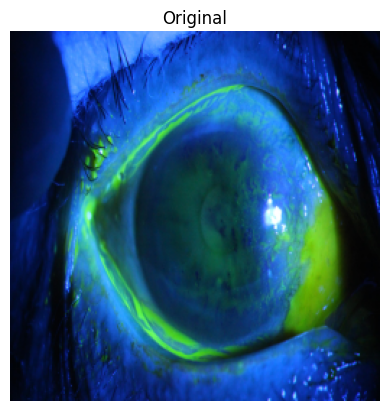

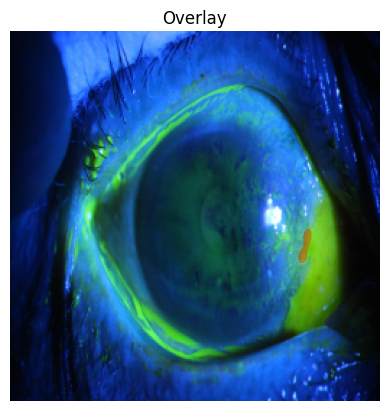

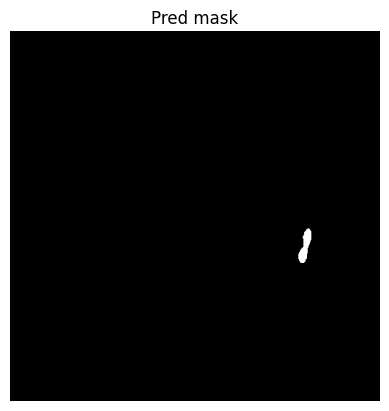

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

out_dir = "outputs/case_001/2026-01-10"

img = Image.open(f"{out_dir}/image_rgb.png")
overlay = Image.open(f"{out_dir}/overlay.png")
mask = Image.open(f"{out_dir}/pred_mask.png")

plt.figure()
plt.imshow(img); plt.axis("off"); plt.title("Original")
plt.show()

plt.figure()
plt.imshow(overlay); plt.axis("off"); plt.title("Overlay")
plt.show()

plt.figure()
plt.imshow(mask, cmap="gray"); plt.axis("off"); plt.title("Pred mask")
plt.show()


In [ ]:
!python src/analysis.py \
  outputs/case_001/2026-01-10/image_rgb.png \
  outputs/case_001/2026-01-10/pred_mask.png \
  outputs/case_001/2026-01-10/metrics_pred.json \
  --case_id case_001 \
  --visit_date 2026-01-10


{
  "case_id": "case_001",
  "visit_date": "2026-01-10",
  "image_path": "outputs/case_001/2026-01-10/image_rgb.png",
  "mask_path": "outputs/case_001/2026-01-10/pred_mask.png",
  "source": "pred",
  "mm_per_pixel": null,
  "area_px": 460,
  "opacity_mean": 173.10398230088495,
  "opacity_ring_mean": 168.91166077738515,
  "opacity_contrast": 4.1923215234998,
  "analysis_flags": [
    "NO_CALIBRATION_MM_PER_PIXEL"
  ],
  "blur_laplacian_var": 158.9486846923828
}


In [ ]:
!python src/report.py \
  outputs/case_001 \
  outputs/case_001/report_case_001.pdf \
  outputs/case_001/2026-01-10


PDF saved: outputs/case_001/report_case_001.pdf


In [ ]:
from google.colab import files
files.download("outputs/case_001/report_case_001.pdf")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>